# libraries and Data Loading 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [36]:
columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[columns]

In [37]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


# EDA

skewness: 0.08


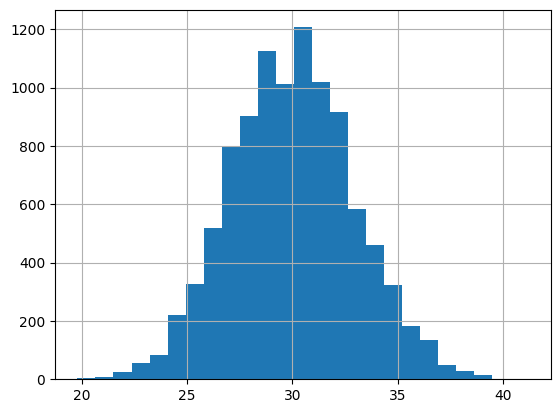

In [38]:
print('skewness:', round(df['fuel_efficiency_mpg'].skew(), 2))
df['fuel_efficiency_mpg'].hist(bins=25)
plt.show()

#### Checking for missing values

In [39]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

#### Median of horsepower

In [40]:
df['horsepower'].median()

254.0

#### Filling Null values with 0 or mean

In [41]:
def data_split(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test

def train_linreg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)

    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

def predict(X, w0, w):
    return w0 + X.dot(w)

def rmse(y, y_pred):
    error = y_pred - y
    return np.sqrt((error ** 2).mean())

def get_X_y(df_part, fill_value):
    df_part = df_part.fillna(fill_value)
    y = df_part['fuel_efficiency_mpg'].values
    X = df_part.drop(columns=['fuel_efficiency_mpg']).values
    return X, y

#### data split using function

In [42]:
df_train, df_val, df_test = data_split(df, seed=42)

#### Filling na with 0

In [ ]:
X_train, y_train = get_X_y(df_train, 0)
X_val, y_val = get_X_y(df_val, 0)
w0, w = train_linreg(X_train, y_train)
score_zero = round(rmse(y_val, predict(X_val, w0, w)), 3)

RMSE with 0 = 2.205


#### Filling na with mean

In [ ]:
hp_mean = df_train['horsepower'].mean()
X_train, y_train = get_X_y(df_train, {'horsepower': hp_mean})
X_val, y_val = get_X_y(df_val, {'horsepower': hp_mean})
w0, w = train_linreg(X_train, y_train)
score_mean = round(rmse(y_val, predict(X_val, w0, w)), 3)

RMSE with mean = 2.202


#### Comparing them both


In [46]:
print("RMSE with 0    =", score_zero)
print("RMSE with mean =", score_mean)

RMSE with 0    = 2.205
RMSE with mean = 2.202


#### Regularization to find best RMSE

In [47]:
X_train, y_train = get_X_y(df_train, 0)
X_val, y_val = get_X_y(df_val, 0)

best_r = None
best_score = None 

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linreg(X_train, y_train, r=r)
    score = round(rmse(y_val, predict(X_val, w0, w)), 4)
    print('r =', r, 'RMSE =', score)

    if best_score is None or score < best_score:
        best_score = score
        best_r = r

print()
print('best r=', best_r)

r = 0 RMSE = 2.2053
r = 0.01 RMSE = 2.2058
r = 0.1 RMSE = 2.2241
r = 1 RMSE = 2.3492
r = 5 RMSE = 2.4094
r = 10 RMSE = 2.4195
r = 100 RMSE = 2.4292

best r= 0


#### RMSE Standard deviation 

In [49]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test = data_split(df, seed)
    X_train, y_train = get_X_y(df_train, 0)
    X_val, y_val = get_X_y(df_val, 0)

    w0, w = train_linreg(X_train, y_train)
    scores.append(rmse(y_val, predict(X_val, w0, w)))

print('Std =', round(np.std(scores), 3))

Std = 0.029


#### combining train, validation, ``r=0.001``, RMSE on test set

In [50]:
df_train, df_val, df_test = data_split(df, seed=9)
df_full_train = pd.concat([df_train, df_val])

X_full, y_full = get_X_y(df_full_train, 0)
X_test, y_test = get_X_y(df_test, 0)

w0, w = train_linreg(X_full, y_full, r=0.001)
print('rmse test =', round(rmse(y_test, predict(X_test, w0, w)), 3))

rmse test = 2.236
